# Consumer Reviews: How Much Weight do Words Hold? - Data Mining CSCE 676
---
## Motivation & Introduction

A majority of data mining focuses on analyzing different numerical values and measurements in order to form conclusions about data and predict future trends in analyses. However, in some cases, numerical data cannot fully encompass critical details that contribute to the overall structure of the data. For example, in reviews, textual context and tone is often overlooked when data is aggregated, and although a numerical rating can provide an overview, the nuances left in the literary part of the reviews are overlooked and therefore certain trends are ignored. The purpose of this project is to compare the numerical ratings (on a scale of 1 to 5) of reviews to equivalent measures of tone and context of the reviews themselves. For this brand specifically, given its reputation and elevated status plus certain weak areas in recent years, how can studying the tone of consumer reviews help strategists change the direction of the company in order to continue success? This led me to pose and pursue the following research questions:
1. How does the overall customer sentiment towards the brand compare to the given numerical rating across all reviews?
2. What topics are most prevalent across customer reviews?

## The Dataset: Selection Crtieria and Drawbacks
In theory, locating a well-rounded collection of consumer reviews for the same brand can be difficult, especially considering the obvious self-selection bias present in self-reporting forums. However, the dataset chosen for this project was aggregated using web scrapting techniques that collected reviews across different internet sources for not just this vehicle brand but for countless others. Although the ideal environment would ensure enough representation from different groups of users from different geographical locations, vehicle year, vehicle model, vehicle type, etc. the web scraping offers assurance of collection from multiple sources as opposed to one such as the brand's own website - which would be an unfair basis as they would choose to portray their best reviews and ratings. Before preprocessing, the dataset contained 2429 entries and was cut to 1627 following the removal of empty/incomplete columns. Additionally, formatting was applied to split the date column into separate ones for individual access and analysis per each unit of time. Finally, ratings were rounded to the nearest half measure or 0.5 to ensure a clearer discrete separation.

In [4]:
#Load reviews.csv into a pd.DataFrame named car_rev
import pandas as pd
import matplotlib.pyplot as plt

#Read and initial view of data
car_rev = pd.read_csv('Scraped_Car_Review_porsche.csv', on_bad_lines='skip', engine='python')
print(car_rev.info())
print()

#clean/preprocess data
car_rev = car_rev.dropna(subset=['Review', 'Rating'])
car_rev = car_rev.drop_duplicates()
clean_time = car_rev['Review_Date'].str.extract(r'(\d{2}/\d{2}/\d{2} \d{2}:\d{2} [AP]M)')[0] #remove "on"
car_rev['Review_Date_dt'] = pd.to_datetime(clean_time, format='%m/%d/%y %H:%M %p') #add formatting for the date column to extract dates in numeric
car_rev['Rating'] = ((car_rev["Rating"] * 2).round() / 2)#round ratings to nearest 0.5 for concrete comparison when gathering sentiment
car_rev['Year'] = car_rev['Review_Date_dt'].dt.year #extract just the year for each entry

#Initial View of data size and columns
print("Rows: " + str(car_rev.shape[0]) + " Columns: " + str(car_rev.shape[1]))
print()
print(car_rev.info())
print()
print(car_rev.head(n=5))

#EDA: Column exploration
vehicle_counts = car_rev['Vehicle_Title'].value_counts(ascending=False, normalize=False)
ratings = car_rev['Rating'].value_counts(ascending=False, normalize=False)
review_len = car_rev['Review'].str.len()
year_count = car_rev['Review_Date_dt'].dt.year.value_counts(ascending=False, normalize=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2429 entries, 0 to 2428
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     2425 non-null   object 
 1   Review_Date    1941 non-null   object 
 2   Author_Name    1784 non-null   object 
 3   Vehicle_Title  1784 non-null   object 
 4   Review_Title   1784 non-null   object 
 5   Review         1784 non-null   object 
 6   Rating         1627 non-null   float64
dtypes: float64(1), object(6)
memory usage: 133.0+ KB
None

Rows: 1627 Columns: 9

<class 'pandas.core.frame.DataFrame'>
Index: 1627 entries, 0 to 2428
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Unnamed: 0      1627 non-null   object        
 1   Review_Date     1627 non-null   object        
 2   Author_Name     1627 non-null   object        
 3   Vehicle_Title   1627 non-null   object        
 4

## Text Mining: Sentiment Analysis
To get started with the actual text mining aspect of review analysis, I made the design choice to begin with pursuing my first research question. I chose TextBlob to carry out sentiment analysis since it offered ease of usage and subjected the data to less parameter tuning upfront. TextBlob relies on PatternAnalyzing in order to arrive at conclusions for specific words in a sentence. It offers two scores; polarity and subjectivity, and leaving the variable analysis to the interpretability of said values. Sentiment polarity scores are assigned on a scale of -1 (negative) to 1 (positive), and sentiment subjectivity scores are assigned on a scale of 0 (objective) to 1 (subjective) (Watson 2024). The following cell involves installing packages needed for TextBlob. Following that is the actual execution of the TextBlob sentiment analysis on each review. I chose this approach as opposed to running the algorithm on each sentence for each review for time complexity and to support the idea of getting a well-rounded tone from a review as a whole, and not have the sentiment polarity or subjectivity be skewed by individual sentence analysis. The polarity and subjectivity scores were collected and stored in lists to be transferred into new dataframe columns.

In [5]:
from textblob import TextBlob #use textblob for sentiment analysis

#make lists to extract both polarity and subjectivity scores
sentiment_polarity_scores = []
sentiment_subjectivity_scores = []

for review in car_rev['Review']:
  blob = TextBlob(review)
  sentiment_polarity_scores.append(blob.sentiment.polarity)
  sentiment_subjectivity_scores.append(blob.sentiment.subjectivity)

car_rev['Sentiment Polarity'] = sentiment_polarity_scores
car_rev['Sentiment Subjectivity'] = sentiment_subjectivity_scores

[0.4248076923076924, -0.14722222222222223, 0.4303571428571429, -0.0031250000000000028, 0.06805555555555556, 0.21708333333333335, 0.12079889807162535, 0.2333333333333333, 0.0, 0.296308954203691, 0.0, 0.2265625, 0.2156108352431882, 0.16876984126984126, 0.3833333333333333, 0.54, 0.207439393939394, 0.0625, 0.14574299223235393, 0.23846153846153845, 0.1787037037037037, 0.4, 0.0, 0.11045454545454546, 0.3451831501831502, 0.32, 0.35, 0.45, 0.8, 0.3666666666666667, 0.23567927170868347, 0.08055555555555556, 0.32142857142857145, 0.06964285714285713, 0.7222222222222222, 0.0, -0.07291666666666667, 0.13545606440343283, -0.2, 0.4069444444444444, 0.12727272727272723, 0.14583333333333334, -0.028310335497835494, 0.25, 0.23833333333333334, 0.19999999999999998, 0.6666666666666666, 0.0, -0.149266975308642, 0.2769494047619047, 0.06755555555555556, 0.3, 0.14306039777021923, 1.0, 0.6333333333333334, 0.16214646464646465, 0.32887291280148423, 0.19444444444444445, 1.0, 0.0, 0.4666666666666666, 0.0, 0.365104166666

## Text Mining: Sentiment Analysis Results & Interpretation
After retrieving values for both sentiment polarity and subjectivity, I decided on a boxplot to get an accuracte overview of the sentiment distribution of each review. First is the boxplot comparing the average numerical ratings on a scale from 0 to 5 to the sentiment polarity score, and the second boxplot compares the same ratings to the sentiment subjectivity score. Upon first glance, we can see that sentiment polarity steadily increases as the numerical rating does. Although it isn't drastic, the growth is offset by the fact that the average polarity median starts at about 0 as opposed to a negative value assumed to be associated with a lower rated review. As the ratings increase, so do the number of outliers whose sentiment polarity doesn't exactly match that of their rating. This is where the context of the review is the most important - reviews can be extremely positive or negative but the consumer may not choose to rate as strongly, or vice versa. Another angle to consider is that every individual's perception of "good vs. bad" is different and very subjective. This plays a role into the staggering discrepancies especially with reviews rated a full 5.0, as this rating not only has the highest polarity but the highest number and widest spread of outliers. This leads us to the next plot showcasing sentiment subjectivity against numerical rating. Although the median subjectivity for each rating leans a bit more subjective, all around most reviews average at the midpoint. A stark difference between this plot and the previous is the immediate presence of outliers even in the lower ratings, notably one with a very  objective rating of 1.0/5.0, similar to a polar opposite outlier signifying both wildly subjective and objective reviews of 5.0/5.0.

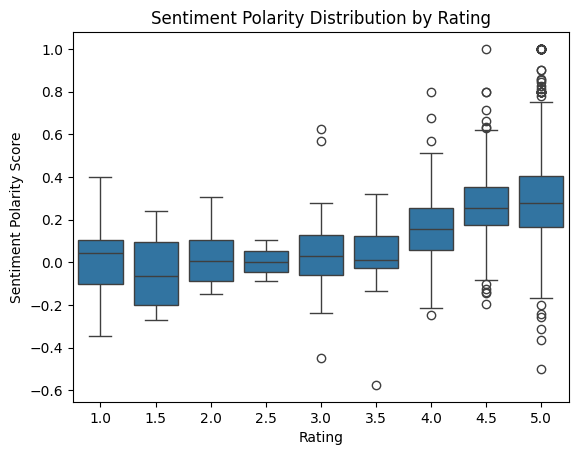

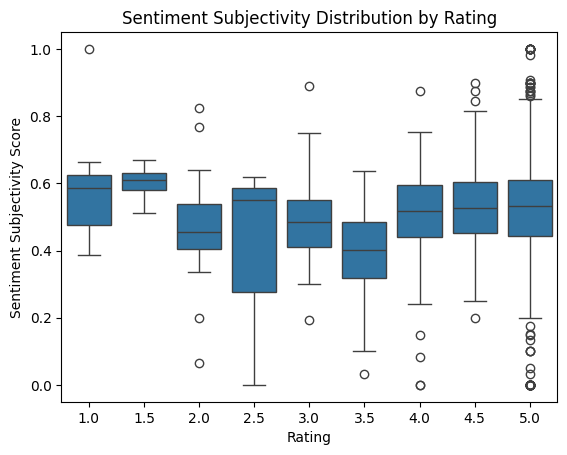

In [6]:
#Use seaborn to visualize data results in box and scatter plot form

import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=car_rev['Rating'], y=car_rev['Sentiment Polarity'])

plt.title('Sentiment Polarity Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Sentiment Polarity Score')
plt.show()

sns.boxplot(x=car_rev['Rating'], y=car_rev['Sentiment Subjectivity'])

plt.title('Sentiment Subjectivity Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Sentiment Subjectivity Score')
plt.show()

## Text Mining: Connecting Insights & Further Observations

After viewing both the polarity and sensitivity visualizations, I wanted to compare average sentiment polarity over the years of reviews to see if there were any trends or patterns to be extract. Porsche consumers left reviews with a much more positive sentiment in the early 2000s than the present, but steadily starts to decline as 2010 approached. It notably dips around 2011-2013, plummeting the polarity to a mean of about 0.15 at the lowest. This trend specifically was noted somewhere else in my data exploration, and i wanted to bring it back and compare. The review counts across the web by year are visualized right below the first polarity graph, and it sure enough shows a similar trend: althogh some years do not match the trend of the polarity, the years that saw the least number of reviews left are the same which had such a low polarity. How did this gap in data affect the polarity so much? Was it due to an error web scraping or did the brand face a difficult market that year due to a different reason? Regardles, the reviews that were left clearly supported a less than stellar sentiment towards the brand. But how do these occasional critiques affect the numerical ratings over the year? That's what I graphed next. The last graph shows the mean ratings per year. With an average not starting below a 4, it is obvious how  ratings differ from the type of review given, supporting the fact that companies need to focus on actual sentiment value of consumer reviews, not just ratings. Analyzing the sentiment - even if still positive - allows for the discovery of niche trends or patterns that could reflect a poor consumer reaction to certain business or design choices. It would be most beneficial to analyze sentiment of customers immediately after a new rebrand or launch to expect how to handle future ones for the best accpetance and outcome.

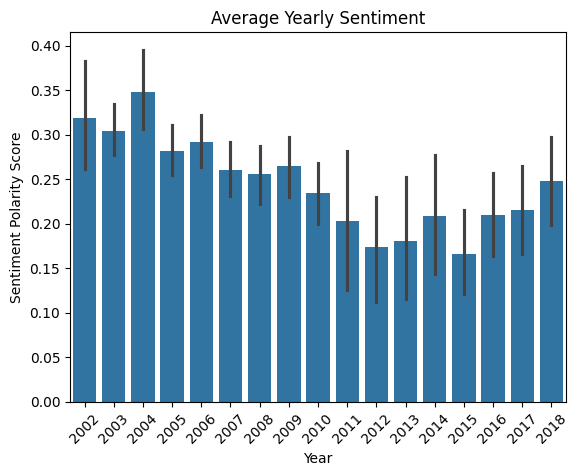

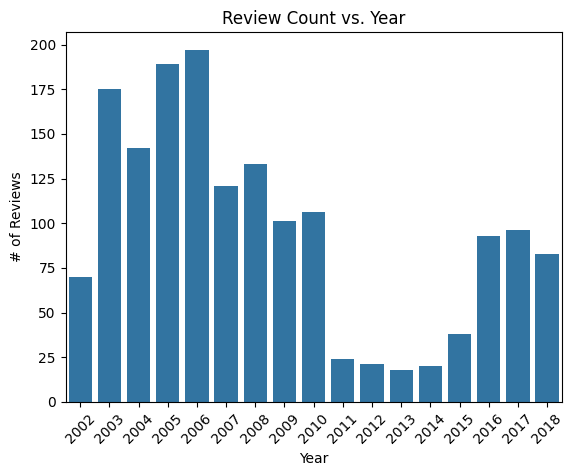

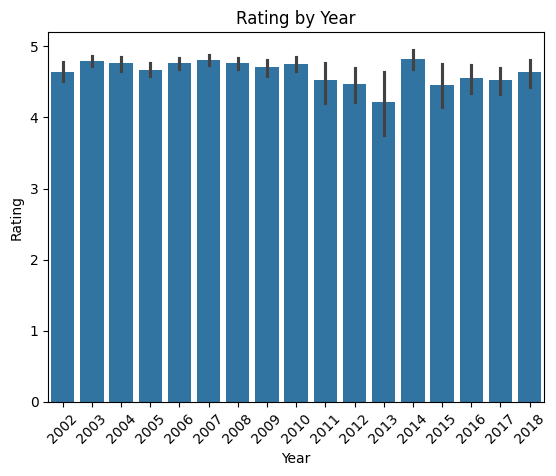

In [8]:
#Review Sentiment Polarity vs Year and compare to Rating vs Year

sns.barplot(x=car_rev['Year'], y=car_rev['Sentiment Polarity'])
plt.xticks(rotation=45)
plt.title('Average Yearly Sentiment')
plt.xlabel('Year')
plt.ylabel('Sentiment Polarity Score')
plt.show()

#number of reviews over the years
sns.barplot(x=year_count.index, y=year_count.values)
plt.xticks(rotation=45)
plt.title('Review Count vs. Year')
plt.xlabel('Year')
plt.ylabel('# of Reviews')
plt.show()

sns.barplot(x=car_rev['Year'], y=car_rev['Rating'])
plt.xticks(rotation=45)
plt.title('Rating by Year')
plt.xlabel('Year')
plt.ylabel('Rating')
plt.show()

## Text Mining: Topic Modeling

Now that we have successfully answered our first research question and discovered an overall trend of sentiment polarity and subjective, we can now look at extracting common topics across reviews and how they compare to the average rating and sentiment that year. In order to achieve a clear topic modeling simulation, further preprocessing of the text reviews are needed to remove stopwords and punctuation. I started by copying over data and manipulating it to fit the new criteria. After that I will choose my topic modeling algorithm.

In [9]:
#Create dataframe copy for car review and change review
import re #text cleaning

top_mod = car_rev.copy()

#clean/preprocess data
top_mod = top_mod.dropna(subset=['Review', 'Rating'])
top_mod = top_mod.drop_duplicates()
clean_time = top_mod['Review_Date'].str.extract(r'(\d{2}/\d{2}/\d{2} \d{2}:\d{2} [AP]M)')[0] #remove "on"
top_mod['Review_Date_dt'] = pd.to_datetime(clean_time, format='%m/%d/%y %H:%M %p') #add formatting for the date column to extract dates in numeric
top_mod['Rating'] = ((top_mod["Rating"] * 2).round() / 2)#round ratings to nearest 0.5 for concrete comparison when gathering sentiment
top_mod['Year'] = top_mod['Review_Date_dt'].dt.year #extract just the year for each entry

#for each review, prep
for review in top_mod['Review']:
  top_mod['Review'] = review.lower()
  top_mod['Review'] = top_mod['Review'].apply(lambda x: re.sub(r'[^a-z\s]', '', x)) #add preprocessing cleaning to remove anything that isn't alphabetical letters


## Preprocessing/Stopword Removal, & Feature Extraction
There is one specific algorithm known for topic modeling: the Latent Dirichlet Allocation or LDA model. This model curates topics based on a set of prevalent words in the data. The LDA model has a components parameter which directly translates to the number of resulting topics, each categorized by a subset of popular high importance words. In order to ensure the clearest distinction is made for each topic, common stopwords that don't contribute to the semantic meaning of a review should be removed. Additionally, after initial algorithm fit, I will be varying the results for different values of component parameters to analyze its influence on the algorithm outcome. Starting with stopwords below, the common English stopwords are used as a base and I made the decision to update the dictionary to include a few words I noticed in my results that were not conducive to individual topic extraction (such as "I" or "Ive"). Following the stopword removal I transformed the data into the numerical matrix expected by LDA using the Count Vectorizer.

In [11]:
import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
nltk.download('stopwords') #stopword generation
from sklearn.feature_extraction.text import CountVectorizer #feature extraction matrix

stopwords = nltk.corpus.stopwords.words('english') #set stopwords
stopwords.extend(["ive", "i", "im"])

top_mod['Review'] = top_mod['Review'].apply(#create cleaned reviews free of stopwords
    lambda x: " ".join([word for word in x.split() if word not in stopwords])) #split words up, remove stopwords, and joins remaining left

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(top_mod['Review'])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## LDA Initialization
From here, I imported and initialized the LDA model and fit it on the vector X previously generated. The next step involved extracting feature names (or all learned words) from the data. To actually curate topics however, I created a dictionary that would house a topic for each component along with the top 10 words that determined a review's topic. A closer look at these two outputs allowed me to realize what words seemed redundant and didn't offer much individualistic value to the overall topic extraction. Finally, after one pass of the algorithm, I noticed how similar the topics seemed to be, especially since boxing over 1000 reviews worth of discussion into just 3 categories would not encapsulate every individual point made. Therefore, I will fit the model again, keeping the same random state but varying the components to best compare results.

In [43]:
from sklearn.decomposition import LatentDirichletAllocation

#variable components but keep random state for result regeneration
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X)

words = vectorizer.get_feature_names_out() #extract word names from LDA model

topics = {} #create/extract topics - name for number of components
for i, topic in enumerate(lda.components_): #for each 3 initial components
    topics[f"Topic {i+1}"] = [words[i] for i in topic.argsort()[-10:]] #top 5 highest rated topics according to importance

print(topics)

{'Topic 1': ['boxster', 'taken', 'bought', 'even', 'better', 'drive', 'one', 'much', 'faster', 'car'], 'Topic 2': ['model', 'snow', 'package', 'faster', 'drive', 'one', 'better', 'much', 'even', 'car'], 'Topic 3': ['go', 'would', 'road', 'much', 'even', 'better', 'one', 'faster', 'drive', 'car']}


## LDA: Component Selection
When selecting the number of components to start my LDA with, I did some research to conclude what would be an appropriate number of topics for a dataset the size of mine. Starting at 3 gave me a good amount of room to view different other spreads while ensuring enough separation. When choosing other k values for component parameters, I didn't want to go lower than 3 since 2 topics would be too general for reviews of this size. The beneficial insights that topic modeling could bring to consumer review lie in the diversity of the topics and even how they overlap. However a distinct and larger number is preferable to be able to divide topics into specific issues in order to address them later. I chose 5 different k component values increasing in value to generate topics for and then created a dataframe with the final collection of data.

In [14]:
#rerun LDA algorithm for multiple different values of components
rows = []

components = [3,4,5,6,7] #5 different component levels to compare

for k in components: #for each component
  lda = LatentDirichletAllocation(n_components=k, random_state=42) #run and fit LDA with same random state but k components
  lda.fit(X)

  words = vectorizer.get_feature_names_out() #extract word names from LDA model

  row = {"n_topics": k} #label rows based off of component

  for i, topic in enumerate(lda.components_):
      row[f"Topic {i+1}"] = [words[j] for j in topic.argsort()[-10:]]

  rows.append(row)

all_tops = pd.DataFrame(rows) #global dataframe for holding topics for all component levels at each row

In [44]:
all_tops.head()

,n_topics,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7
0,3,"[boxster, taken, bought, even, better, drive, ...","[model, snow, package, faster, drive, one, bet...","[go, would, road, much, even, better, one, fas...",NaN,NaN,NaN,NaN
1,4,"[used, bought, taken, even, better, drive, one...","[trips, premium, package, drive, one, faster, ...","[taken, road, go, much, better, even, drive, o...","[lighting, would, boxster, much, faster, even,...",NaN,NaN,NaN
2,5,"[snow, much, garage, see, drivingupdate, model...","[trips, premium, package, drive, one, faster, ...","[taken, road, go, much, even, better, drive, o...","[lighting, would, boxster, much, faster, even,...","[snow, much, garage, see, drivingupdate, model...",NaN,NaN
3,6,"[club, pdk, though, model, much, garage, trips...","[trips, premium, package, drive, one, faster, ...","[taken, road, go, much, even, better, one, dri...","[lighting, would, boxster, much, faster, even,...","[club, pdk, though, model, much, garage, trips...","[purchasing, would, rock, much, better, even, ...",NaN
4,7,"[mileage, garage, find, solid, though, model, ...","[drivingupdate, premium, package, drive, faste...","[go, road, recommend, much, better, drive, eve...","[lighting, would, boxster, much, faster, even,...","[mileage, garage, find, solid, though, model, ...","[mileage, garage, find, solid, though, model, ...","[solid, find, mileage, even, one, better, fast..."


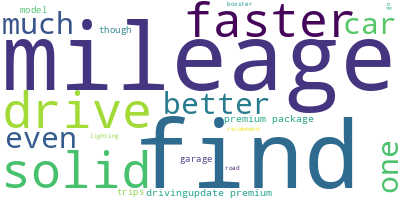

In [47]:
#from Medium: word chart - create visualization of topics with 7 components (includes all earliers)

# Import the wordcloud library
from wordcloud import WordCloud

# Join words across the topics
row = all_tops[all_tops['n_topics'] == 7]

long_string = ' '.join(
    word
    for topic_list in row.drop(columns=['n_topics']).values.flatten()
    for word in topic_list
)

# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=5000, contour_width=3, contour_color='steelblue')

# Generate a word cloud
wordcloud.generate(long_string)

# Visualize the word cloud
wordcloud.to_image()

## Word Cloud and Topic Distribution

Aggregating topic words from different component parameters allows an insight into some of the buzzwords ranked highest among the context of the consumer reviews. Many of these words highlight improvements and steady performance of the brand, whereas others point to areas that could either be categorized as pain points or strengths. A deeper look at the actual topic makeup in the dataframe allows for subjective analysis that could be useful to data analysts at the company to form connections between certain review topics and the year they were left, the car that was purchased, and the company/brand standing at the time. Viewing the varying component values, Topic 1 seemed to be variable even after being established the first round. Whereas Topic 2 and 3 stayed completely identical even during replication efforts with higher component values for the LDA. Topic 1 suggests that the premium package could be correlated with faster performance and a better mileage, with Topic 2 in agreement. Topic 3 mentions a possible recommendation of this brand/car, Topic 4 touches on the Boxster's speed and lighting, Topic 5 mentions model performance in the snow, Topic 6 exhibits an enthusiastic tone towards the purchase of the vehicle, and Topic 7 circles back to match the tone of the 1st. Although these topics can be refined by removing further stopwords and adverbs that seem redundant, a closer look into popular review topics allow brands to see what design choices or products are being well received and use them to further expand and predict how consumers would receive it.

# Final Discussion
After delving into both sentiment analysis and topic modeling for the Porsche Consumer Review dataset, it is important to note that both metrics are equally important and are both necessary in order to form a well rounded conclusion from the data. Knowing a particular user sentiment without identifying the topics associated with it is just as useless as discovering topics without knowing how the consumer attitude is toward each one. Using both together offers a unique window into the opinions of the target audience. This combination of analyses concludes that user sentiment generally follows the trend that the ratings do, however individual topics are much more unique and often follow themes surrounding car performance, luxury feel, and reliability. Consistent results prove that consumer reviews would be accurate and reliable baselines to use as indicators of brand recognition and attitude, as well as to discover what further features or products would be best received by the market. Although numerical data figures are crucial for the success of any company, the unique angle brought in by text mining allows companies to understand more about their target audience and how best to cater the company, image, and branding to them in order to deliver in all aspects.

# Resources

On my honor, I declare the following resources:
1. Collaborators:
- Myself, consulted Project Checkpoint 1 and 2 code to copy EDA results and word cloud for continuation

2. Web Sources:
- https://www.kaggle.com/datasets/ankkur13/edmundsconsumer-car-ratings-and-reviews?select=Scraped_Car_Review_porsche.csv: Web Scraped Porsche Consumer Review Dataset
- https://medium.com/@eleanor.watson/a-beginners-guide-to-performing-sentiment-analysis-on-text-with-python-3ce80dcac22e: Overview of sentiment analysis, what tool to use and what outputs it gave
- https://medium.com/@nafisaidris413/a-beginners-guide-for-product-review-sentiment-analysis-0de1f451167d: understanding motivations and uses for sentiment analysis
- https://textblob.readthedocs.io/en/dev/: TextBlob documentation for sentiment analysis
- https://medium.com/@sayahfares19/text-analysis-topic-modelling-with-spacy-gensim-4cd92ef06e06: Discovering different topic models
- https://medium.com/data-science/end-to-end-topic-modeling-in-python-latent-dirichlet-allocation-lda-35ce4ed6b3e0: Understanding LDA
- https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html#sklearn.decomposition.LatentDirichletAllocation.get_feature_names_out: LDA Functions and documentation for model instance and fit
- https://medium.com/@rahulpoonia1997/topic-modelling-for-labelling-large-text-collections-b8c6335db0cd: Understanding how best to interpet topic modeling results in a review context
3. AI Tools:
ChatGPT:
- Consulted for design outline so I didn't miss any steps
- Asked for help refining plots and interpreting them
- Asked for help to aggregate topics in one data structure during topic modeling
- Consulted when choosing my algorithms especially when ensuring runtime was acceptable
- Asked for debugging on my lambda function for splitting stopwords in topic modeling
- Asked for help debugging k component loop assignment for topic modeling
- Asked for help creating a .gitignore suitable for the environment

4. Papers:
- None